# XGBoost Challenger Model

This notebook tests one focused challenger: **XGBoost trained on the same engineered features and chronological split as the selected LightGBM model**.

The challenger is evaluated at:

- the default `0.50` threshold; and
- a threshold selected to achieve at least 80% validation recall.

> `is_attributed = 1` means an attributed app installation, not confirmed fraud.

## 1. Imports and settings

If XGBoost is not installed, run `pip install xgboost` in the project environment before continuing.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "development_features.parquet"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "is_attributed"
TIME_COLUMN = "click_time"
VALIDATION_START = pd.Timestamp("2017-11-07 14:30:00")
TARGET_RECALL = 0.80
RANDOM_STATE = 42

RAW_FEATURES = ["ip", "app", "device", "os", "channel"]
CATEGORICAL_FEATURES = ["app", "device", "os", "channel"]
EXCLUDED_COLUMNS = {TARGET, TIME_COLUMN, "attributed_time"}

print(f"XGBoost version: {xgb.__version__}")
print(f"Dataset: {DATA_PATH}")

XGBoost version: 3.4.0
Dataset: d:\Projects\Ad_Click_Fraud_Detection\data\processed\development_features.parquet


## 2. Load and validate the processed dataset

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)

required_columns = set(RAW_FEATURES + [TIME_COLUMN, TARGET])
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not pd.api.types.is_datetime64_any_dtype(df[TIME_COLUMN]):
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], errors="raise")

if df[TARGET].isna().any() or not set(df[TARGET].unique()).issubset({0, 1}):
    raise ValueError(f"{TARGET} must contain only 0 and 1 with no missing values.")

if not df[TIME_COLUMN].is_monotonic_increasing:
    raise ValueError(f"{TIME_COLUMN} is not chronologically sorted.")

if not df[TIME_COLUMN].min() < VALIDATION_START <= df[TIME_COLUMN].max():
    raise ValueError("VALIDATION_START is outside the dataset time range.")

ENGINEERED_FEATURES = [
    column for column in df.columns
    if column not in EXCLUDED_COLUMNS
]
ADDED_ENGINEERED_FEATURES = [
    column for column in ENGINEERED_FEATURES
    if column not in RAW_FEATURES
]

if not ADDED_ENGINEERED_FEATURES:
    raise ValueError("No engineered features were found.")

non_numeric = [
    column for column in ENGINEERED_FEATURES
    if not pd.api.types.is_numeric_dtype(df[column])
]
if non_numeric:
    raise TypeError(f"Non-numeric model columns found: {non_numeric}")

missing_values = int(df[ENGINEERED_FEATURES].isna().sum().sum())
infinite_values = int(np.isinf(df[ENGINEERED_FEATURES].to_numpy()).sum())
if missing_values or infinite_values:
    raise ValueError(
        f"Invalid feature values — missing: {missing_values:,}, "
        f"infinite: {infinite_values:,}"
    )

print("All dataset validations passed.")
print(f"Rows: {len(df):,}")
print(f"Engineered features: {len(ENGINEERED_FEATURES)}")
print(f"Attributed clicks: {int(df[TARGET].sum()):,} ({df[TARGET].mean():.6%})")
print("\nFeatures used:")
for feature in ENGINEERED_FEATURES:
    print(f"  - {feature}")

All dataset validations passed.
Rows: 6,397,036
Engineered features: 16
Attributed clicks: 15,775 (0.246599%)

Features used:
  - ip
  - app
  - device
  - os
  - channel
  - click_day
  - click_hour
  - click_minute
  - click_second
  - click_day_of_week
  - previous_ip_clicks
  - previous_ip_app_clicks
  - previous_ip_channel_clicks
  - seconds_since_previous_ip_click
  - seconds_since_previous_ip_app_click
  - seconds_since_previous_ip_channel_click


## 3. Chronological split

The split is identical to the LightGBM experiment: training clicks occur before 14:30 and validation clicks occur from 14:30 onward.

In [3]:
train_mask = df[TIME_COLUMN] < VALIDATION_START
validation_mask = ~train_mask

X_train = df.loc[train_mask, ENGINEERED_FEATURES].copy()
X_validation = df.loc[validation_mask, ENGINEERED_FEATURES].copy()
y_train = df.loc[train_mask, TARGET]
y_validation = df.loc[validation_mask, TARGET]

# Learn category definitions from training data only. Unseen validation
# categories become missing values, which XGBoost handles natively.
for column in CATEGORICAL_FEATURES:
    categories = pd.Index(X_train[column].unique())
    dtype = pd.CategoricalDtype(categories=categories)
    X_train[column] = X_train[column].astype(dtype)
    X_validation[column] = X_validation[column].astype(dtype)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_validation)],
    "attributed_clicks": [int(y_train.sum()), int(y_validation.sum())],
    "attribution_rate_percent": [y_train.mean() * 100, y_validation.mean() * 100],
}, index=["Training", "Validation"])

display(split_summary.style.format({
    "rows": "{:,.0f}",
    "attributed_clicks": "{:,.0f}",
    "attribution_rate_percent": "{:.6f}%",
}))

,rows,attributed_clicks,attribution_rate_percent
Training,"4,866,118","12,689",0.260762%
Validation,"1,530,918","3,086",0.201578%


## 4. Build and train the XGBoost challenger

The model uses histogram-based tree building for efficiency. `scale_pos_weight` gives the rare attributed class greater importance and is calculated only from the training set. Early stopping prevents unnecessary trees.

In [4]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

print(f"Training negatives: {negative_count:,}")
print(f"Training positives: {positive_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgboost_model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    enable_categorical=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=50,
)

print(f"Best iteration: {xgboost_model.best_iteration}")

Training negatives: 4,853,429
Training positives: 12,689
scale_pos_weight: 382.49
[0]	validation_0-aucpr:0.18566
[50]	validation_0-aucpr:0.43966
[100]	validation_0-aucpr:0.50569
[150]	validation_0-aucpr:0.52158
[200]	validation_0-aucpr:0.52523
[250]	validation_0-aucpr:0.52737
[300]	validation_0-aucpr:0.52732
[350]	validation_0-aucpr:0.52740
[369]	validation_0-aucpr:0.52676
Best iteration: 319


## 5. Evaluate the challenger

The final PR-AUC is calculated with scikit-learn, exactly as it was for LightGBM. This avoids comparing differently implemented training-log metrics.

In [5]:
def evaluate_predictions(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


validation_probabilities = xgboost_model.predict_proba(X_validation)[:, 1]
default_metrics = evaluate_predictions(
    y_validation,
    validation_probabilities,
    threshold=0.50,
)

display(pd.DataFrame([default_metrics], index=["XGBoost — threshold 0.50"]))

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
XGBoost — threshold 0.50,0.528682,0.500000,0.983909,0.101701,0.891445,0.182572,1503533,24299,335,2751


## 6. Select the 80%-recall threshold

In [6]:
curve_precision, curve_recall, thresholds = precision_recall_curve(
    y_validation,
    validation_probabilities,
)

valid_indexes = np.where(curve_recall[:-1] >= TARGET_RECALL)[0]
if len(valid_indexes) == 0:
    raise ValueError(f"No threshold achieved {TARGET_RECALL:.0%} recall.")

# Among thresholds meeting the recall target, retain the highest precision.
best_index = valid_indexes[np.argmax(curve_precision[:-1][valid_indexes])]
selected_threshold = float(thresholds[best_index])
target_recall_metrics = evaluate_predictions(
    y_validation,
    validation_probabilities,
    threshold=selected_threshold,
)

threshold_comparison = pd.DataFrame(
    [default_metrics, target_recall_metrics],
    index=["Default threshold", "Minimum 80% recall"],
)
display(threshold_comparison.style.format({
    "pr_auc": "{:.6f}",
    "threshold": "{:.6f}",
    "accuracy": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "true_negatives": "{:,.0f}",
    "false_positives": "{:,.0f}",
    "false_negatives": "{:,.0f}",
    "true_positives": "{:,.0f}",
}))

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
Default threshold,0.528682,0.500000,0.983909,0.101701,0.891445,0.182572,"1,503,533","24,299",335,"2,751"
Minimum 80% recall,0.528682,0.932477,0.994524,0.241231,0.800065,0.370693,"1,520,066","7,766",617,"2,469"


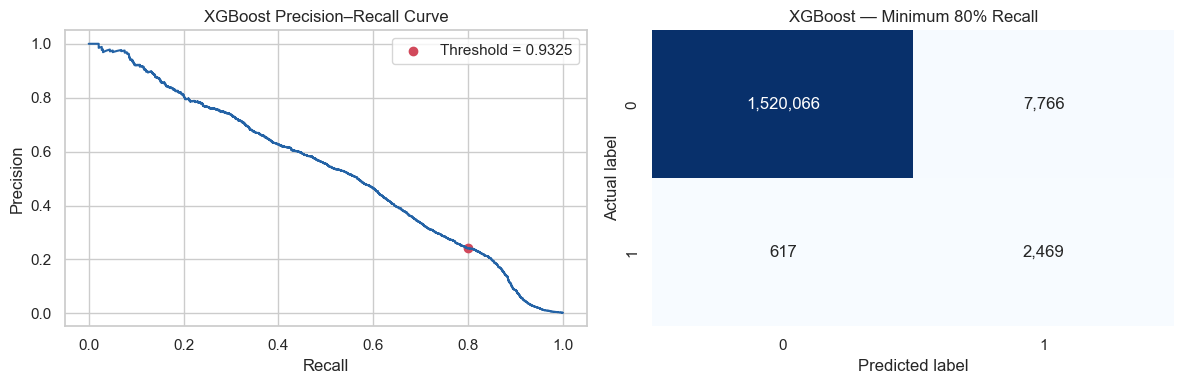

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curve_recall, curve_precision, color="#2463A6")
axes[0].scatter(
    curve_recall[best_index],
    curve_precision[best_index],
    color="#D1495B",
    label=f"Threshold = {selected_threshold:.4f}",
)
axes[0].set_title("XGBoost Precision–Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

target_predictions = (validation_probabilities >= selected_threshold).astype(np.uint8)
target_cm = confusion_matrix(y_validation, target_predictions, labels=[0, 1])
sns.heatmap(target_cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("XGBoost — Minimum 80% Recall")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")
plt.tight_layout()
plt.show()

## 7. Compare XGBoost with the selected LightGBM

The LightGBM values below come from the completed chronological-validation experiment. PR-AUC determines which algorithm is the stronger probability-ranking model. The 80%-recall rows compare their operational trade-offs.

In [8]:
# Recorded engineered LightGBM results from notebook 03.
LIGHTGBM_PR_AUC = 0.538654
LIGHTGBM_80_RECALL = {
    "model": "LightGBM",
    "pr_auc": 0.538654,
    "threshold": 0.959165,
    "accuracy": 0.995303,
    "precision": 0.273029,
    "recall": 0.800065,
    "f1": 0.407123,
    "true_negatives": 1_521_258,
    "false_positives": 6_574,
    "false_negatives": 617,
    "true_positives": 2_469,
}

xgboost_80_recall = {"model": "XGBoost", **target_recall_metrics}
algorithm_comparison = (
    pd.DataFrame([LIGHTGBM_80_RECALL, xgboost_80_recall])
    .set_index("model")
    .sort_values("pr_auc", ascending=False)
)

display(algorithm_comparison.style.format({
    "pr_auc": "{:.6f}",
    "threshold": "{:.6f}",
    "accuracy": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "true_negatives": "{:,.0f}",
    "false_positives": "{:,.0f}",
    "false_negatives": "{:,.0f}",
    "true_positives": "{:,.0f}",
}))

xgboost_pr_auc = target_recall_metrics["pr_auc"]
winner = "XGBoost" if xgboost_pr_auc > LIGHTGBM_PR_AUC else "LightGBM"
difference = abs(xgboost_pr_auc - LIGHTGBM_PR_AUC)
print(f"Selected by validation PR-AUC: {winner}")
print(f"Absolute PR-AUC difference: {difference:.6f}")

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
model,,,,,,,,,,
LightGBM,0.538654,0.959165,0.995303,0.273029,0.800065,0.407123,"1,521,258","6,574",617,"2,469"
XGBoost,0.528682,0.932477,0.994524,0.241231,0.800065,0.370693,"1,520,066","7,766",617,"2,469"


Selected by validation PR-AUC: LightGBM
Absolute PR-AUC difference: 0.009972


## 8. Save the challenger and metadata

The challenger is saved separately. It does not replace `final_lightgbm_model.joblib`; replacement should happen only after reviewing the comparison.

In [9]:
MODEL_PATH = MODEL_DIR / "xgboost_challenger.joblib"
METADATA_PATH = MODEL_DIR / "xgboost_challenger_metadata.json"

metadata = {
    "model_name": "XGBoost engineered-feature challenger",
    "model_type": "XGBClassifier",
    "target": TARGET,
    "positive_class_meaning": "Click led to an attributed app installation",
    "validation_start": VALIDATION_START.isoformat(),
    "selection_metric": "validation_pr_auc",
    "threshold_method": "minimum_80_percent_validation_recall",
    "decision_threshold": selected_threshold,
    "features": ENGINEERED_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "scale_pos_weight": scale_pos_weight,
    "best_iteration": int(xgboost_model.best_iteration),
    "validation_metrics_default_threshold": default_metrics,
    "validation_metrics_80_percent_recall": target_recall_metrics,
    "lightgbm_reference_pr_auc": LIGHTGBM_PR_AUC,
    "validation_pr_auc_winner": winner,
    "library_versions": {
        "xgboost": xgb.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

joblib.dump(xgboost_model, MODEL_PATH)
with METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved challenger: {MODEL_PATH}")
print(f"Saved metadata: {METADATA_PATH}")

Saved challenger: d:\Projects\Ad_Click_Fraud_Detection\models\xgboost_challenger.joblib
Saved metadata: d:\Projects\Ad_Click_Fraud_Detection\models\xgboost_challenger_metadata.json


## Final decision rule

- Prefer the model with the higher chronological-validation PR-AUC.
- If PR-AUC values are nearly identical, prefer LightGBM because it is already the established, simpler project model.
- Compare precision and false positives at the shared 80% recall policy before making the final operational decision.
- Do not describe either model as detecting confirmed fraud; the label records attributed installations.